# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


PROYEK Membangun Sistem Machine Learning (MSML) – ADVANCED
Prediksi Customer Churn Menggunakan Dataset Churn Modelling

Dataset:
Kaggle: https://www.kaggle.com/datasets/osama12bin/churn-model-dataset/data

File yang digunakan: Churn_Modelling.csv

Tujuan proyek digunakan untuk:

Memprediksi apakah customer akan churn atau tidak.
Membuat sistem machine learning end-to-end.
Melakukan preprocessing.
Training dan hyperparameter tuning.
Monitoring model.
Logging inference.
Visualisasi Grafana.
Alerting system.
Deployment sederhana.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# =========================================================
# Import Library
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# =========================================================
# DATA LOADING
# =========================================================

df = pd.read_csv(
    '../BC-Churn_raw/Churn_Modelling.csv'
)

print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
# =========================================================
# DATA INFORMATION
# =========================================================

print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  1000

In [4]:
# ======================================================
# CEK MISSING VALUE
# ======================================================

print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [5]:
# ======================================================
# CEK DUPLICATE DATA
# ======================================================

print('Jumlah duplicate:', df.duplicated().sum())

Jumlah duplicate: 0


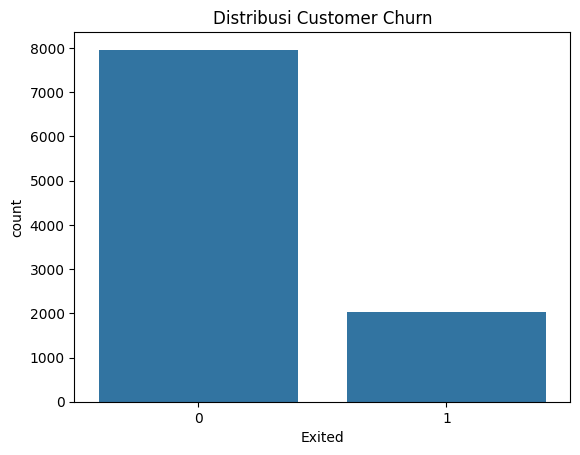

In [6]:
# ======================================================
# DISTRIBUSI TARGET
# ======================================================

sns.countplot(x='Exited', data=df)
plt.title('Distribusi Customer Churn')
plt.show()

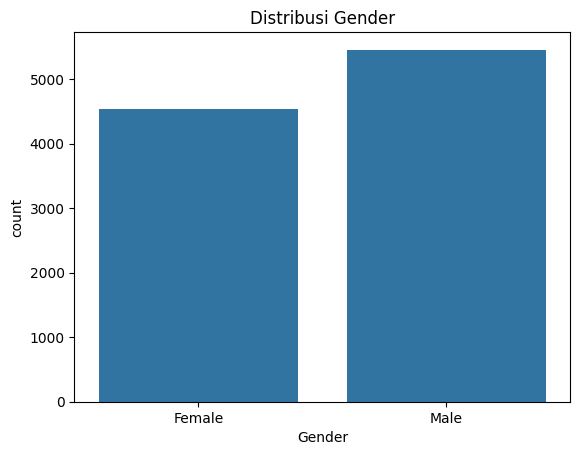

In [7]:
# ======================================================
# DISTRIBUSI GENDER
# ======================================================

sns.countplot(x='Gender', data=df)
plt.title('Distribusi Gender')
plt.show()

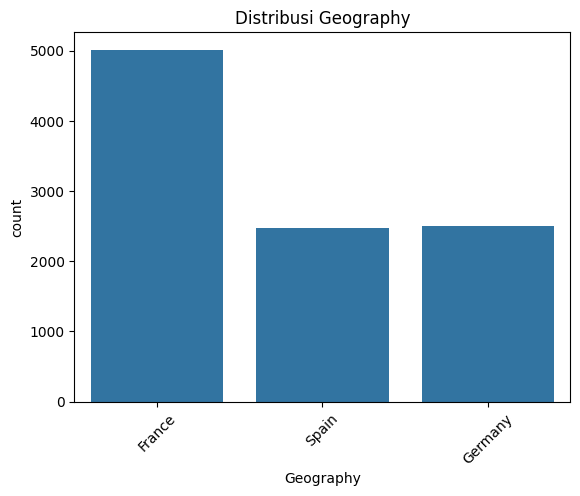

In [8]:
# ======================================================
# DISTRIBUSI GEOGRAPHY
# ======================================================

sns.countplot(x='Geography', data=df)
plt.title('Distribusi Geography')
plt.xticks(rotation=45)
plt.show()

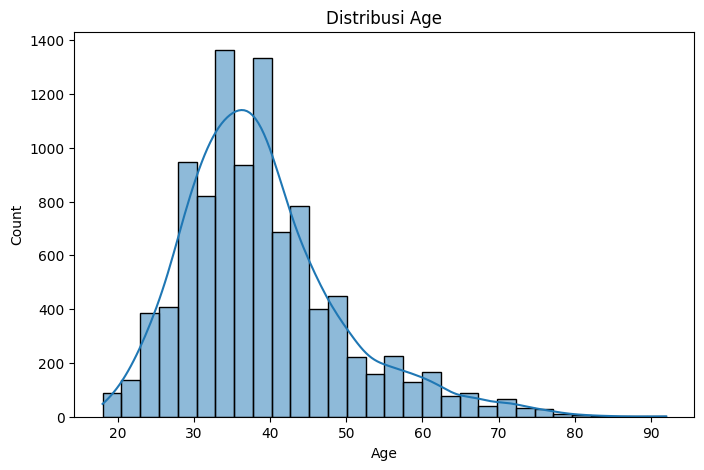

In [9]:
# ======================================================
# DISTRIBUSI AGE
# ======================================================

plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title('Distribusi Age')
plt.show()

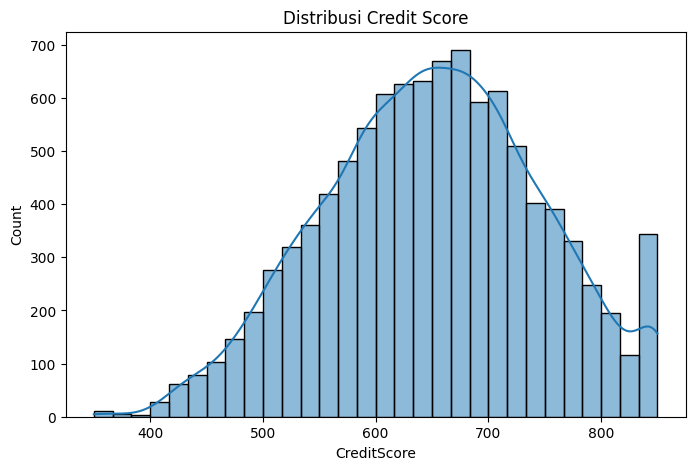

In [10]:
# ======================================================
# DISTRIBUSI CREDIT SCORE
# ======================================================

plt.figure(figsize=(8,5))

sns.histplot(df['CreditScore'], bins=30, kde=True)

plt.title('Distribusi Credit Score')
plt.show()

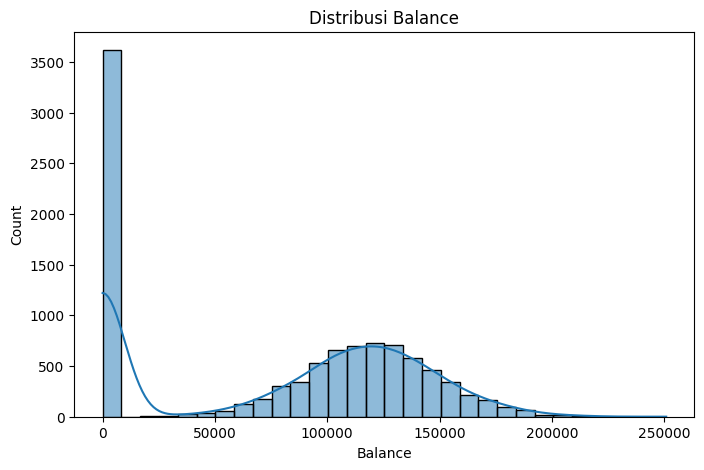

In [11]:
# ======================================================
# DISTRIBUSI BALANCE
# ======================================================

plt.figure(figsize=(8,5))

sns.histplot(df['Balance'], bins=30, kde=True)

plt.title('Distribusi Balance')
plt.show()

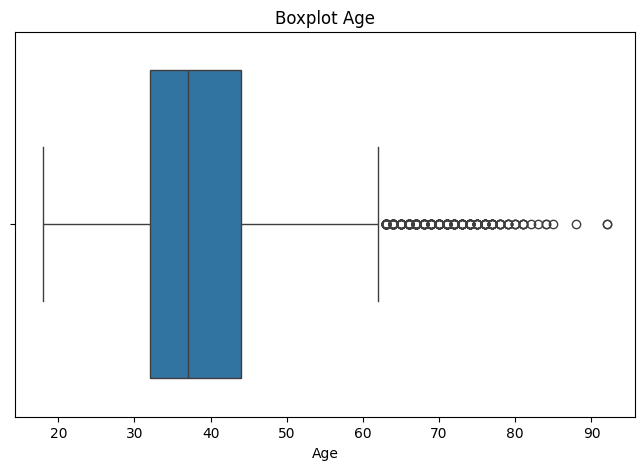

In [12]:
# ======================================================
# BOXPLOT AGE
# ======================================================

plt.figure(figsize=(8,5))

sns.boxplot(x=df['Age'])

plt.title('Boxplot Age')
plt.show()

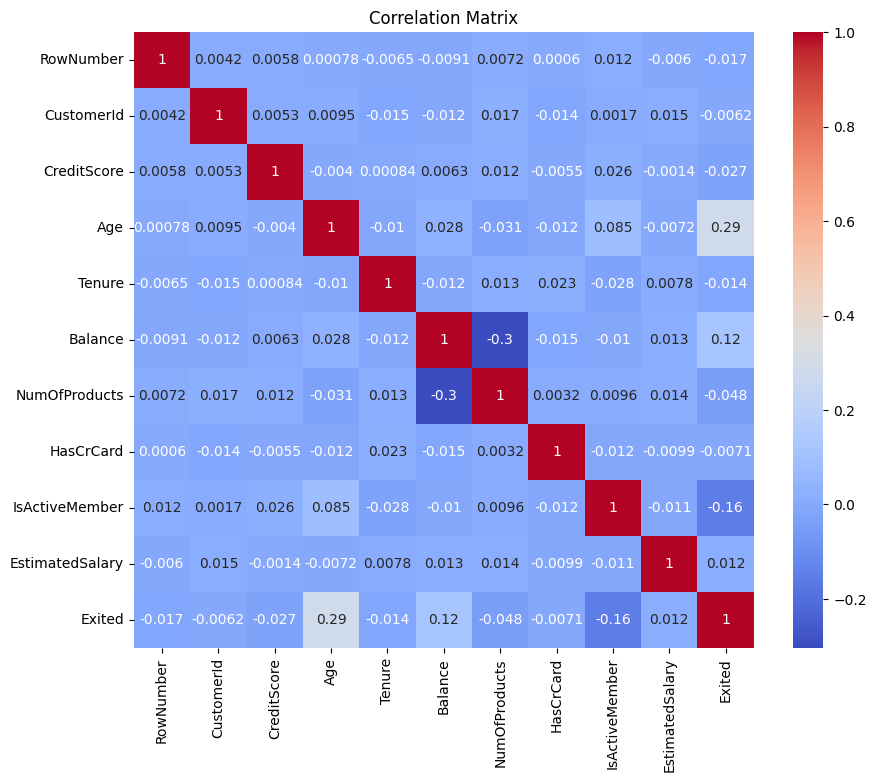

In [13]:
# ======================================================
# CORRELATION MATRIX
# ======================================================

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [14]:
# ======================================================
# DROP COLUMN
# ======================================================

df_clean = df.drop(
    columns=['RowNumber', 'CustomerId', 'Surname']
)

print(df_clean.head())

   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  


In [15]:
# ======================================================
# LABEL ENCODING
# ======================================================

le_gender = LabelEncoder()
le_geo = LabelEncoder()

df_clean['Gender'] = le_gender.fit_transform(df_clean['Gender'])

df_clean['Geography'] = le_geo.fit_transform(df_clean['Geography'])

print(df_clean.head())

   CreditScore  Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619          0       0   42       2       0.00              1   
1          608          2       0   41       1   83807.86              1   
2          502          0       0   42       8  159660.80              3   
3          699          0       0   39       1       0.00              2   
4          850          2       0   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  


In [16]:
# ======================================================
# SPLIT FEATURE DAN TARGET
# ======================================================

X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

In [17]:
# ======================================================
# TRAIN TEST SPLIT
# ======================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('X_train shape :', X_train.shape)
print('X_test shape :', X_test.shape)

X_train shape : (8000, 10)
X_test shape : (2000, 10)


In [18]:
# ======================================================
# FEATURE SCALING
# ======================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Feature scaling berhasil')

Feature scaling berhasil


In [19]:
# ======================================================
# SAVE PREPROCESSING RESULT
# ======================================================

# Mengubah hasil scaling menjadi dataframe
df_preprocessing = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

# Menambahkan target
df_preprocessing['Exited'] = y_train.values

# Menyimpan hasil preprocessing
df_preprocessing.to_csv(
    'Churn_Modelling_preprocessing.csv',
    index=False
)

print('Dataset preprocessing berhasil disimpan')

Dataset preprocessing berhasil disimpan
